In [1]:
# ── Configuration ───────────────────────────────────────────────────────────────────────
EPSILON = 4 / 255
ALPHA = 1 / 255           # step size
STEPS = 10                # PGD-10 for training
PGD_BATCH = 64
SEED = 42                 # for reproducible random init
ATTACK_SPLITS = ['Training', 'Validation']

In [2]:
!pip install ultralytics -q

import csv, os, shutil, zipfile, time
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name()}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.0 MB/s eta 0:00:0000:01
Device: cuda
GPU: NVIDIA L4


In [3]:
from google.colab import drive
drive.mount('/content/drive')

BASE_SAVE_DIR = '/content/drive/MyDrive/recaptcha dataset with rare samples'
DATASET_ROOT = '/content/recaptcha-dataset-master'
TRAIN_DIR = os.path.join(DATASET_ROOT, 'Training')
VAL_DIR = os.path.join(DATASET_ROOT, 'Validation')

if not os.path.isdir(DATASET_ROOT):
    with zipfile.ZipFile(os.path.join(BASE_SAVE_DIR, 'recaptcha-dataset-master.zip'), 'r') as z:
        z.extractall('/content')
    print('Extracted.')
else:
    print('Dataset ready.')

from ultralytics import YOLO
MODEL_DST = '/content/classification_model.pt'
if not os.path.exists(MODEL_DST):
    shutil.copy(os.path.join(BASE_SAVE_DIR, 'classification_model.pt'), MODEL_DST)

yolo = YOLO(MODEL_DST)
torch_model = yolo.model.to(device).eval()

def forward_probs(x):
    out = torch_model(x.to(device))
    return out[0] if isinstance(out, tuple) else out

IMG_SIZE = 128; N_CLASSES = 13
CLASS_NAMES = yolo.names
NAME_TO_IDX = {v: k for k, v in CLASS_NAMES.items()}
SPLIT_TO_DIR = {'Training': TRAIN_DIR, 'Validation': VAL_DIR}
preprocess = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor()])

import PIL.Image
_original_open = PIL.Image.open.__wrapped__ if hasattr(PIL.Image.open, '__wrapped__') else PIL.Image.open

def tensor_to_pil(t):
    arr = (t.clamp(0, 1).permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    return Image.fromarray(arr)

def load_image_tensor(path):
    return preprocess(_original_open(path).convert('RGB'))

# Verify model output type
with torch.no_grad():
    test_dir = os.path.join(TRAIN_DIR, CLASS_NAMES[0])
    test_files = sorted([f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg','.png'))])
    out = forward_probs(load_image_tensor(os.path.join(test_dir, test_files[0])).unsqueeze(0)).cpu().squeeze()
    print(f'Model output: min={out.min():.4f}, max={out.max():.4f}, sum={out.sum():.4f}')
    assert abs(out.sum().item() - 1.0) < 0.01, 'Model should output probabilities in eval mode'
    print('✓ Model outputs probabilities (sum≈1) in eval mode')

# Print dataset stats
total_images = 0
for split_name in ATTACK_SPLITS:
    print(f'\n{split_name}:')
    for idx in range(N_CLASSES):
        cn = CLASS_NAMES[idx]
        cd = os.path.join(SPLIT_TO_DIR[split_name], cn)
        n = len([f for f in os.listdir(cd) if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp'))]) if os.path.isdir(cd) else 0
        total_images += n
        print(f'  {cn:>14s}: {n:>5d}')
print(f'\nTotal: {total_images} images')

Mounted at /content/drive
Extracted.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model output: min=0.0002, max=0.9400, sum=1.0000
✓ Model outputs probabilities (sum≈1) in eval mode

Training:
         Bicycle:   726
          Bridge:   479
             Bus:  1155
             Car:  3504
         Chimney:    39
       Crosswalk:  1186
         Hydrant:   898
      Motorcycle:    27
        Mountain:    11
           Other:  1395
            Palm:   858
          Stairs:    75
   Traffic Light:   737

Validation:
         Bicycle:    74
          Bridge:    74
             Bus:    74
             Car:    74
         Chimney:    17
       Crosswalk:    74
         Hydrant:    74
      Motorcycle:    74
        Mountain:     2


In [4]:
# Output directory
eps_tag = f'pgd_eps{EPSILON * 255:.0f}'
SAVE_ROOT = os.path.join(BASE_SAVE_DIR, f'all_samples_untargeted_{eps_tag}_v2')
ADV_DIR = os.path.join(SAVE_ROOT, 'adversarial_images')
RESULTS_CSV = os.path.join(SAVE_ROOT, 'results.csv')
os.makedirs(SAVE_ROOT, exist_ok=True)

print(f'Attack: PGD-{STEPS} with random init')
print(f'  ε = {EPSILON*255:.0f}/255')
print(f'  α = {ALPHA*255:.1f}/255')
print(f'  steps = {STEPS}')
print(f'  batch = {PGD_BATCH}')
print(f'  save: {SAVE_ROOT}')

# Resume support
existing_keys = set()
if os.path.exists(RESULTS_CSV):
    with open(RESULTS_CSV) as f:
        existing_keys = {(r['split'], r['class_name'], r['filename']) for r in csv.DictReader(f)}
    print(f'Resuming: {len(existing_keys)} existing rows')

csv_file = open(RESULTS_CSV, 'a', newline='')
csv_writer = csv.writer(csv_file)
if len(existing_keys) == 0:
    csv_writer.writerow(['split', 'class_name', 'filename', 'clean_pred', 'clean_conf',
                         'adv_pred', 'adv_conf', 'success',
                         'adv_pred_png', 'adv_conf_png', 'success_png', 'adv_path'])

saved_count = 0; skipped_count = 0
successful_f32 = 0; successful_png = 0
torch.manual_seed(SEED)  # reproducible random init for PGD
total_t0 = time.time()

for split_name in ATTACK_SPLITS:
    split_dir = SPLIT_TO_DIR[split_name]
    print(f'\n{"="*80}')
    print(f'Processing: {split_name}')
    print(f'{"="*80}')

    for true_idx in range(N_CLASSES):
        class_name = CLASS_NAMES[true_idx]
        class_dir = os.path.join(split_dir, class_name)
        if not os.path.isdir(class_dir): continue

        files = sorted([f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp'))])
        adv_class_dir = os.path.join(ADV_DIR, split_name, class_name)
        os.makedirs(adv_class_dir, exist_ok=True)

        to_process = [f for f in files if (split_name, class_name, f) not in existing_keys]
        if not to_process:
            skipped_count += len(files)
            print(f'  {class_name:>14s} | {len(files):>4d} files | all skipped')
            continue

        imgs = []
        valid_fnames = []
        for fname in to_process:
            try:
                imgs.append(load_image_tensor(os.path.join(class_dir, fname)))
                valid_fnames.append(fname)
            except: pass

        class_success_f32 = 0; class_success_png = 0
        for batch_start in range(0, len(imgs), PGD_BATCH):
            batch_imgs = torch.stack(imgs[batch_start:batch_start+PGD_BATCH]).to(device)
            batch_labels = torch.tensor([true_idx]*batch_imgs.shape[0], device=device)

            delta = (torch.rand_like(batch_imgs) * 2 - 1) * EPSILON
            delta = delta.detach().requires_grad_(True)

            # Clean predictions (before attack)
            with torch.no_grad():
                clean_probs = forward_probs(batch_imgs)

            # PGD loop
            with torch.enable_grad():
                for _ in range(STEPS):
                    xadv = torch.clamp(batch_imgs + delta, 0, 1)
                    probs = forward_probs(xadv)
                    loss = F.nll_loss(torch.log(probs + 1e-8), batch_labels)
                    loss.backward()
                    with torch.no_grad():
                        delta.data += ALPHA * delta.grad.sign()
                        delta.data.clamp_(-EPSILON, EPSILON)
                        delta.data = torch.clamp(batch_imgs + delta.data, 0, 1) - batch_imgs
                    delta.grad.zero_()

            adv_batch = torch.clamp(batch_imgs + delta, 0, 1).detach().cpu()

            with torch.no_grad():
                adv_probs_f32 = forward_probs(adv_batch.to(device)).cpu()

            for j in range(adv_batch.shape[0]):
                idx = batch_start + j
                fname = valid_fnames[idx]
                stem = os.path.splitext(fname)[0]
                adv_path = os.path.join(adv_class_dir, f'{stem}.png')

                # Save PNG
                tensor_to_pil(adv_batch[j]).save(adv_path)

                # Reload PNG and measure actual success
                reloaded = load_image_tensor(adv_path)
                with torch.no_grad():
                    png_probs = forward_probs(reloaded.unsqueeze(0).to(device)).cpu().squeeze()

                cp = clean_probs[j].cpu()
                ap_f32 = adv_probs_f32[j]

                clean_pred = cp.argmax().item()
                adv_pred_f32 = ap_f32.argmax().item()
                adv_pred_png = png_probs.argmax().item()
                success_f32 = int(adv_pred_f32 != true_idx)
                success_png = int(adv_pred_png != true_idx)

                csv_writer.writerow([
                    split_name, class_name, fname,
                    CLASS_NAMES[clean_pred], f'{cp[clean_pred].item():.6f}',
                    CLASS_NAMES[adv_pred_f32], f'{ap_f32[adv_pred_f32].item():.6f}',
                    success_f32,
                    CLASS_NAMES[adv_pred_png], f'{png_probs[adv_pred_png].item():.6f}',
                    success_png, adv_path
                ])
                saved_count += 1
                successful_f32 += success_f32; class_success_f32 += success_f32
                successful_png += success_png; class_success_png += success_png

            csv_file.flush(); torch.cuda.empty_cache()

        print(f'  {class_name:>14s} | {len(files):>4d} files | new={len(valid_fnames):>4d} | f32={class_success_f32:>4d} png={class_success_png:>4d}')

csv_file.close()

print(f'\n{"="*80}')
print(f'Done in {time.time()-total_t0:.0f}s')
print(f'Save root: {SAVE_ROOT}')
print(f'Newly saved: {saved_count}')
print(f'Skipped existing: {skipped_count}')
print(f'Success (float32): {successful_f32}/{saved_count} ({successful_f32/max(saved_count,1):.1%})')
print(f'Success (PNG):     {successful_png}/{saved_count} ({successful_png/max(saved_count,1):.1%})')
print(f'PNG survival rate: {successful_png/max(successful_f32,1):.1%}')

Attack: PGD-10 with random init
  ε = 4/255
  α = 1.0/255
  steps = 10
  batch = 64
  save: /content/drive/MyDrive/recaptcha dataset with rare samples/all_samples_untargeted_pgd_eps4_v2

Processing: Training
         Bicycle |  726 files | new= 726 | f32= 726 png= 726
          Bridge |  479 files | new= 479 | f32= 479 png= 479
             Bus | 1155 files | new=1155 | f32=1155 png=1155
             Car | 3504 files | new=3504 | f32=3504 png=3504
         Chimney |   39 files | new=  39 | f32=  39 png=  39
       Crosswalk | 1186 files | new=1186 | f32=1186 png=1186
         Hydrant |  898 files | new= 898 | f32= 898 png= 898
      Motorcycle |   27 files | new=  27 | f32=  27 png=  27
        Mountain |   11 files | new=  11 | f32=  11 png=  11
           Other | 1395 files | new=1395 | f32=1395 png=1395
            Palm |  858 files | new= 858 | f32= 858 png= 858
          Stairs |   75 files | new=  75 | f32=  75 png=  75
   Traffic Light |  737 files | new= 737 | f32= 737 png= 737

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# Zip adversarial images for fast loading in downstream notebooks
# ══════════════════════════════════════════════════════════════════════════════
zip_path = os.path.join(SAVE_ROOT, 'adversarial_images.zip')
if not os.path.exists(zip_path):
    print('Creating zip...')
    t0 = time.time()
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_STORED) as zf:
        for root, dirs, files in os.walk(ADV_DIR):
            for f in files:
                full = os.path.join(root, f)
                arcname = os.path.relpath(full, os.path.dirname(ADV_DIR))
                zf.write(full, arcname)
    print(f'  Done in {time.time()-t0:.0f}s: {zip_path}')
else:
    print(f'Zip exists: {zip_path}')

# Verify counts
n_adv = sum(1 for r, d, fs in os.walk(ADV_DIR) for f in fs if f.endswith('.png'))
n_csv = 0
with open(RESULTS_CSV) as f:
    n_csv = sum(1 for _ in csv.DictReader(f))
print(f'Adversarial images: {n_adv}')
print(f'CSV rows: {n_csv}')
assert n_adv == n_csv, f'Mismatch: {n_adv} images vs {n_csv} CSV rows'
print('✓ Image count matches CSV count')

Creating zip...
  Done in 24s: /content/drive/MyDrive/recaptcha dataset with rare samples/all_samples_untargeted_pgd_eps4_v2/adversarial_images.zip
Adversarial images: 11849
CSV rows: 11849
✓ Image count matches CSV count


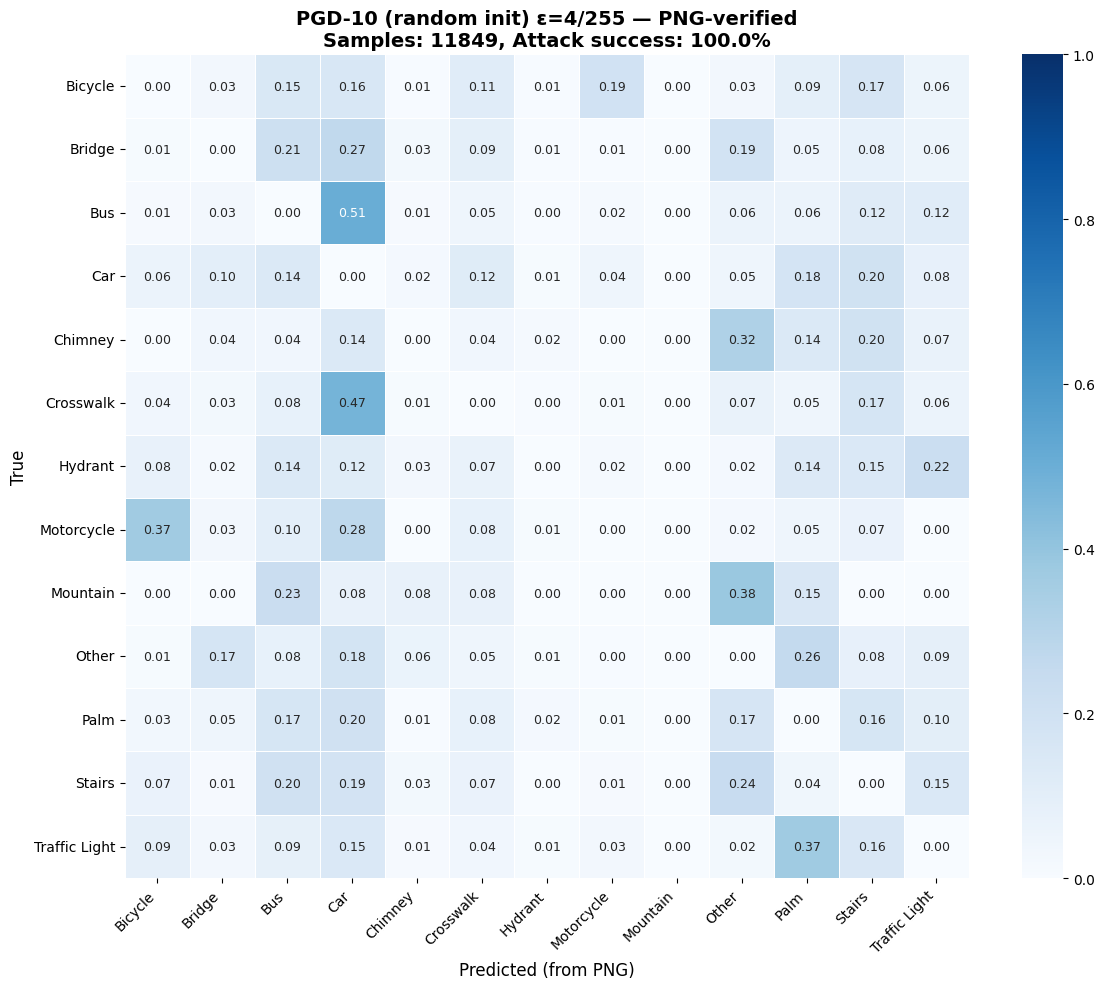


Attack success (float32): 11849/11849 (100.0%)
Attack success (PNG):     11849/11849 (100.0%)
Lost to quantization:     0/11849 (0.0%)

✓ Step 1 v2 complete. Run Step 2 (VLM inference) next.


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# Sanity check: confusion matrix + PNG vs float32 comparison
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns

latest_rows = {}
with open(RESULTS_CSV, 'r', newline='') as f:
    for row in csv.DictReader(f):
        latest_rows[(row['split'], row['class_name'], row['filename'])] = row

# Confusion matrix on PNG-verified predictions
confusion_png = np.zeros((N_CLASSES, N_CLASSES), dtype=int)
n_f32_only = 0
for row in latest_rows.values():
    true_idx = NAME_TO_IDX[row['class_name']]
    if row['adv_pred_png'] not in NAME_TO_IDX: continue
    confusion_png[true_idx, NAME_TO_IDX[row['adv_pred_png']]] += 1
    if int(row['success']) == 1 and int(row['success_png']) == 0:
        n_f32_only += 1

class_labels = [CLASS_NAMES[i] for i in range(N_CLASSES)]
success_rate_png = 1 - np.trace(confusion_png) / max(confusion_png.sum(), 1)

fig, ax = plt.subplots(figsize=(12, 10))
cm_norm = confusion_png.astype(float) / np.maximum(confusion_png.sum(axis=1, keepdims=True), 1)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            vmin=0, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_xlabel('Predicted (from PNG)', fontsize=12); ax.set_ylabel('True', fontsize=12)
ax.set_title(f'PGD-{STEPS} (random init) ε={EPSILON*255:.0f}/255 — PNG-verified\n'
             f'Samples: {confusion_png.sum()}, Attack success: {success_rate_png:.1%}',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, f'confusion_matrix_{eps_tag}_png.png'), bbox_inches='tight', dpi=300)
plt.show()

np.save(os.path.join(SAVE_ROOT, f'confusion_matrix_{eps_tag}_png.npy'), confusion_png)

# Summary
n_total = len(latest_rows)
n_success_f32 = sum(1 for r in latest_rows.values() if int(r['success']) == 1)
n_success_png = sum(1 for r in latest_rows.values() if int(r['success_png']) == 1)
print(f'\nAttack success (float32): {n_success_f32}/{n_total} ({n_success_f32/n_total:.1%})')
print(f'Attack success (PNG):     {n_success_png}/{n_total} ({n_success_png/n_total:.1%})')
print(f'Lost to quantization:     {n_f32_only}/{n_total} ({n_f32_only/n_total:.1%})')
print(f'\n✓ Step 1 v2 complete. Run Step 2 (VLM inference) next.')